In [33]:
'''Step 1 – Import Libraries'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder


In [34]:
'''Step 2 – Load the MNIST Dataset'''
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist.data.astype(np.float32)          # (70000, 784)
y = mnist.target.astype(int)

# Train / Test split (same as Keras default: 60000 train, 10000 test)
x_train, x_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)


Training Images : (60000, 784)
Training Labels : (60000,)
Testing Images  : (10000, 784)
Testing Labels  : (10000,)


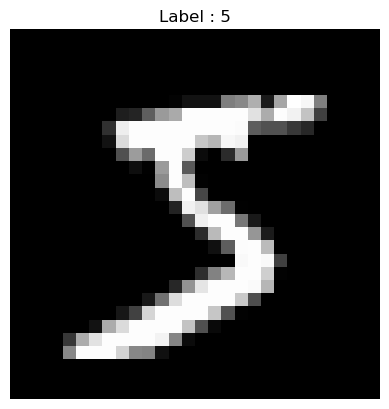

In [18]:
'''Step 3 – Display the First Image'''
plt.imshow(x_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label : {y_train[0]}")
plt.axis("off")
plt.show()


In [19]:
'''Step 4 – Normalize the Images (0-255 → 0-1)'''
x_train = x_train / 255.0
x_test  = x_test  / 255.0
print("Pixel range after normalization:", x_train.min(), "to", x_train.max())


Pixel range after normalization: 0.0 to 1.0


In [20]:
'''Step 5 – Build the MLP Model
Architecture:
  784 Input Pixels
  ↓
  128 Hidden Neurons (ReLU)
  ↓
  10 Output Neurons (Softmax)
  ↓
  Digit Prediction
'''
model = MLPClassifier(
    hidden_layer_sizes=(128,),   # one hidden layer with 128 neurons
    activation='relu',
    solver='adam',
    max_iter=5,
    verbose=True,
    random_state=42,
    warm_start=False
)
print("MLP Model created ✓")
print("Architecture: 784 → 128 (ReLU) → 10 (Softmax)")


MLP Model created ✓
Architecture: 784 → 128 (ReLU) → 10 (Softmax)


In [21]:
'''Step 6 – Model Summary (Layer Details)'''
print("=" * 45)
print("         MLP Model Architecture")
print("=" * 45)
print(f"  Input  Layer  : 784 neurons (28x28 pixels)")
print(f"  Hidden Layer  : 128 neurons  | Activation: ReLU")
print(f"  Output Layer  : 10 neurons   | Activation: Softmax")
print("=" * 45)
print(f"  Solver        : Adam")
print(f"  Loss          : Sparse Categorical Cross-Entropy")
print(f"  Epochs        : 5")
print("=" * 45)


         MLP Model Architecture
  Input  Layer  : 784 neurons (28x28 pixels)
  Hidden Layer  : 128 neurons  | Activation: ReLU
  Output Layer  : 10 neurons   | Activation: Softmax
  Solver        : Adam
  Loss          : Sparse Categorical Cross-Entropy
  Epochs        : 5


In [22]:
'''Step 7 – Train the Model'''
model.fit(x_train, y_train)

# Save per-iteration loss for plotting
training_loss = model.loss_curve_
print(f"\nFinal Training Loss : {training_loss[-1]:.4f}")


Iteration 1, loss = 0.41619415
Iteration 2, loss = 0.19314230
Iteration 3, loss = 0.14447066
Iteration 4, loss = 0.11472999
Iteration 5, loss = 0.09538759

Final Training Loss : 0.0954


/home/joshuaraja/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 3, loss = 0.14447066


Iteration 4, loss = 0.11472999


Iteration 5, loss = 0.09538759

Final Training Loss : 0.0954


/home/joshuaraja/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
'''Step 8 – Evaluate the Model'''
y_pred_test = model.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


Test Accuracy : 97.01%


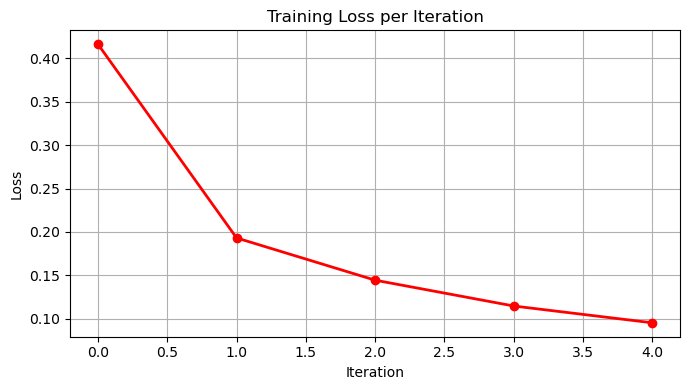

In [24]:
'''Step 9 – Plot Training Loss'''
plt.figure(figsize=(7, 4))
plt.plot(training_loss, marker='o', color='red', linewidth=2)
plt.title("Training Loss per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


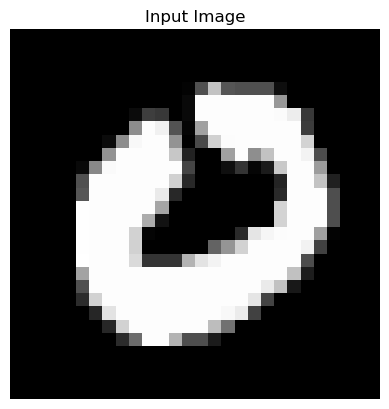

Actual Digit : 0
Predicted Digit : 0


In [25]:
'''Step 10 – Display Input Image and Predict'''
index = 25

plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
plt.title("Input Image")
plt.axis("off")
plt.show()

print("Actual Digit :", y_test[index])

prediction = model.predict(x_test[index:index+1])
print("Predicted Digit :", prediction[0])


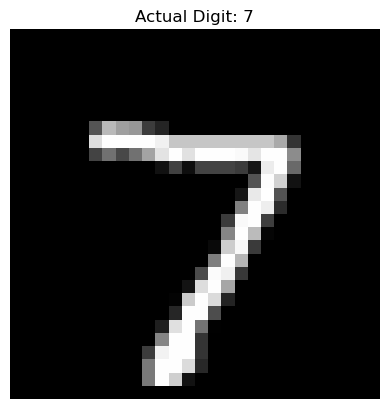

Predicted Digit: 7
Actual Digit   : 7


In [31]:
'''Method 2 – Predict a Specific Digit
Step 1: Find the First Image of a Specific Digit'''

digit = 7
index = np.where(y_test == digit)[0][0]

plt.imshow(x_test[index].reshape(28, 28), cmap="gray")
plt.title(f"Actual Digit: {y_test[index]}")
plt.axis("off")
plt.show()

'''Step 2: Predict the specific input image'''
predicted_digit = model.predict(x_test[index:index+1])[0]
print("Predicted Digit:", predicted_digit)
print("Actual Digit   :", y_test[index])


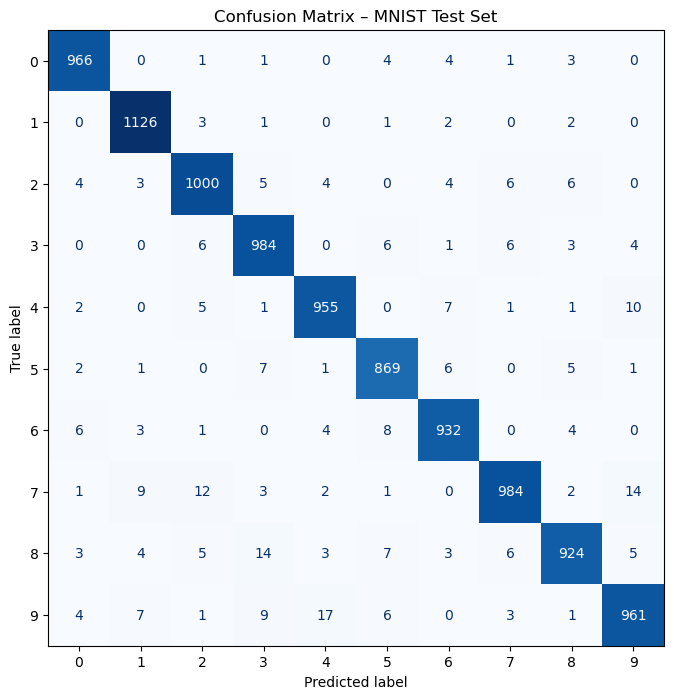

Overall Test Accuracy: 97.01%


In [30]:
'''Step 12 – Confusion Matrix'''
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix – MNIST Test Set')
plt.show()

print(f'Overall Test Accuracy: {np.sum(np.diag(cm)) / np.sum(cm) * 100:.2f}%')


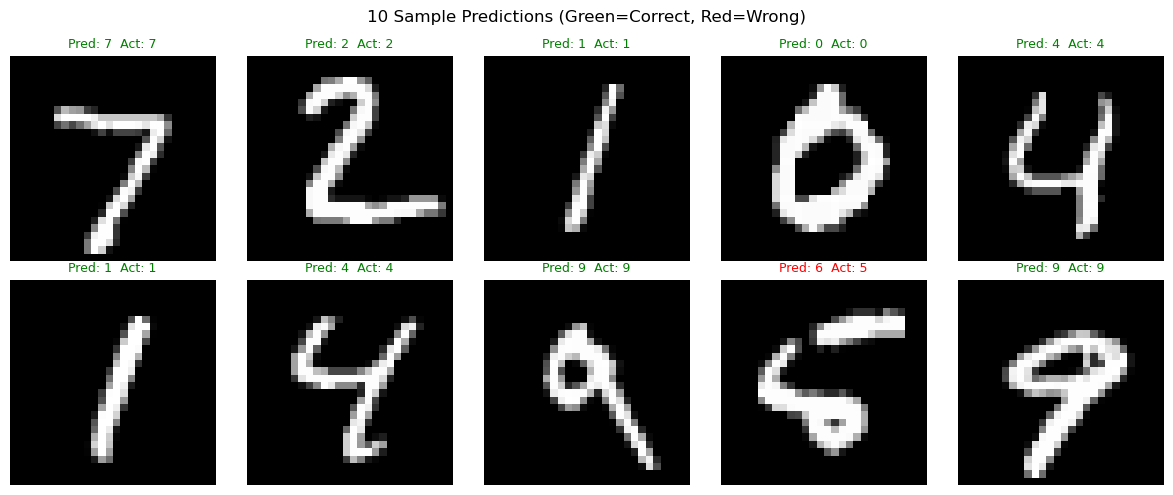

In [29]:
'''Step 13 – Display 10 Sample Predictions'''
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray')
    pred   = model.predict(x_test[i:i+1])[0]
    actual = y_test[i]
    color  = 'green' if pred == actual else 'red'
    ax.set_title(f'Pred: {pred}  Act: {actual}', color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('10 Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()
